# 05 Pretrained CNN Extension

This notebook evaluates a prespecified frozen EfficientNet-B0 model as an extension to the engineered-feature benchmark.

Two prespecified configurations are evaluated: **Frozen EfficientNet-B0 Image Only** and **Frozen EfficientNet-B0 Fusion**. EfficientNet-B0 converts each fixed ROI image into a cached embedding; the fusion configuration adds ERA5, ARPA, and temporal variables under the same unweighted, date-grouped development protocol used in Notebook 4.

EfficientNet-B0 and the stronger-regularization Fusion head were selected using a development-only CNN optimization diagnostic. Notebook 5 evaluates only the selected CNN and its image-only ablation; the common hold-out is not used for tuning and is evaluated once after the development protocol is fixed.

**Inputs:** `data/processed/final_dataset.csv`, `data/interim/image_features.csv`, `config/roi.json`, and CV/hold-out benchmark results exported by Notebook 4

**Output:** `results/deep_learning/`

## Research Questions

**RQ4.** Can automatically learned representations from raw ROI images achieve competitive PM2.5 estimation performance compared with handcrafted image-feature methods?

**RQ5.** Does combining learned image representations with environmental and temporal predictors improve performance over raw-image representations alone?

## Workflow

1. Dataset preparation and common evaluation split
2. Model configuration, frozen embeddings, and evaluation protocol
3. Image-only and Fusion development cross-validation
4. Final Fusion common hold-out evaluation and diagnostics
5. Comparison with the Notebook 4 benchmark models


## Setup


In [1]:
# Import project modules and apply the shared thesis plotting style.
import sys
import json
import importlib
from pathlib import Path

def find_project_root(start_path=None):
    """Find the nearest parent containing the project source and notebooks."""
    start = Path.cwd() if start_path is None else Path(start_path)
    start = start.resolve()

    for candidate in (start, *start.parents):
        if (candidate / "src").is_dir() and (candidate / "notebooks").is_dir():
            return candidate

    raise FileNotFoundError(
        "Could not locate the project root containing src/ and notebooks/."
    )


PROJECT_ROOT = find_project_root()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import torch

import src.config as config
import src.features.evaluation as evaluation
import src.deep_learning.backbones as cnn_backbones
import src.deep_learning.training as cnn_training
import src.deep_learning.plots as cnn_plots
from src.plot_style import (
    COLORS, CONCENTRATION_COLORS, MODEL_FAMILY_COLORS, apply_thesis_style,
)

apply_thesis_style()
config = importlib.reload(config)
evaluation = importlib.reload(evaluation)
cnn_backbones = importlib.reload(cnn_backbones)
cnn_training = importlib.reload(cnn_training)
cnn_plots = importlib.reload(cnn_plots)

RESULTS_DIR = PROJECT_ROOT / "results" / "deep_learning"
RESULTS_DIR.mkdir(parents=True, exist_ok=True)

if torch.cuda.is_available():
    DEVICE = torch.device("cuda")
elif hasattr(torch.backends, "mps") and torch.backends.mps.is_available():
    DEVICE = torch.device("mps")
else:
    DEVICE = torch.device("cpu")

print("Project root:", PROJECT_ROOT)
print("PyTorch:", torch.__version__)
print("Device:", DEVICE)


Project root: /Users/qingxuan/Desktop/webcam-pm25-benchmark
PyTorch: 2.13.0
Device: mps


## 1. Dataset and Unified Split

The same complete-case dataset and deterministic month-balanced date split used in Notebooks 3 and 4 are reproduced here.


### 1.1 Dataset and Experimental Settings


In [2]:
# Load the processed dataset and define shared features and experiment settings.
DATA_PATH = PROJECT_ROOT / "data" / "processed" / "final_dataset.csv"
IMAGE_FEATURE_PATH = PROJECT_ROOT / "data" / "interim" / "image_features.csv"
ROI_PATH = PROJECT_ROOT / "config" / "roi.json"

TARGET = config.TARGET
ALL_FEATURES = config.ALL_FEATURES
TABULAR_FEATURES = config.ERA5_FEATURES + config.ARPA_FEATURES + config.TEMPORAL_FEATURES
FINAL_TEST_SIZE = 0.20
N_SPLITS = 5

SPLIT_RANDOM_STATE = 24
MODEL_RANDOM_STATE = 42

df = pd.read_csv(DATA_PATH, parse_dates=["time"])
required_columns = ["time", TARGET, *ALL_FEATURES]
missing_columns = [column for column in required_columns if column not in df.columns]
if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

display(pd.DataFrame({
    "Item": [
        "Input dataset", "Rows loaded", "Time range",
        "Target", "Engineered predictors", "Tabular fusion predictors",
    ],
    "Value": [
        DATA_PATH.name, len(df),
        f"{df['time'].min():%Y-%m-%d %H:%M} to {df['time'].max():%Y-%m-%d %H:%M}",
        TARGET, len(ALL_FEATURES), len(TABULAR_FEATURES),
    ],
}))


,Item,Value
0,Input dataset,final_dataset.csv
1,Rows loaded,3625
2,Time range,2025-01-29 15:00 to 2026-08-12 21:00
3,Target,PM25
4,Engineered predictors,55
5,Tabular fusion predictors,37


### 1.2 Common Development and Hold-Out Split

Reproduce the deterministic month-balanced, date-disjoint split used in Notebooks 3 and 4. The common hold-out remains unavailable during model development and is evaluated once only after all training choices are fixed.


In [3]:
# Build the complete-case dataset and reproduce the common date-disjoint split.
analysis_df = df[required_columns].dropna().sort_values("time").reset_index(drop=True)
analysis_df["date_group"] = analysis_df["time"].dt.normalize()
development_df, final_test_df = evaluation.balanced_month_group_split(
    analysis_df,
    time_column="time",
    test_size=FINAL_TEST_SIZE,
    random_state=SPLIT_RANDOM_STATE,
)

shared_dates = set(development_df["date_group"]) & set(final_test_df["date_group"])
if shared_dates:
    raise ValueError("Development and final test contain shared dates.")

split_summary = pd.DataFrame({
    "Subset": ["Development", "Locked final test"],
    "Samples": [len(development_df), len(final_test_df)],
    "Independent dates": [
        development_df['date_group'].nunique(),
        final_test_df['date_group'].nunique(),
    ],
})
split_summary["Percentage"] = (
    split_summary["Samples"] / len(analysis_df) * 100
)
display(split_summary.round({"Percentage": 1}))


,Subset,Samples,Independent dates,Percentage
0,Development,2905,167,80.1
1,Locked final test,720,42,19.9


### 1.3 Source-Image and ROI Linkage


In [4]:
# Link observations to source images and load the fixed ROI definition.
image_mapping = pd.read_csv(
    IMAGE_FEATURE_PATH,
    usecols=["datetime", "image_path"],
    parse_dates=["datetime"],
).rename(columns={"datetime": "time"})
if image_mapping["time"].duplicated().any():
    raise ValueError("Duplicate timestamps in image mapping.")

def resolve_image_path(value):
    path = Path(value)
    return path if path.is_absolute() else PROJECT_ROOT / path

image_mapping["image_path"] = image_mapping["image_path"].map(resolve_image_path)

def attach_images(data):
    linked = data.merge(image_mapping, on="time", how="left", validate="many_to_one")
    linked["image_available"] = linked["image_path"].map(
        lambda path: isinstance(path, Path) and path.is_file()
    )
    return linked

development_df = attach_images(development_df)
final_test_df = attach_images(final_test_df)

with open(ROI_PATH, "r") as file:
    ROI_CONFIG = json.load(file)

if not development_df["image_available"].all() or not final_test_df["image_available"].all():
    raise ValueError("One or more observations do not have an available source image.")

display(pd.DataFrame({
    "Subset": ["Development", "Locked final test"],
    "Images available": [
        development_df["image_available"].sum(),
        final_test_df["image_available"].sum(),
    ],
    "Images missing": [
        (~development_df["image_available"]).sum(),
        (~final_test_df["image_available"]).sum(),
    ],
}))


,Subset,Images available,Images missing
0,Development,2905,0
1,Locked final test,720,0


## 2. Model Configuration and Evaluation Protocol

### 2.1 Frozen EfficientNet-B0 Embeddings

The ImageNet-pretrained EfficientNet-B0 backbone is frozen. Each fixed ROI is deterministically transformed into a 1280-dimensional embedding once and cached. Only development images are processed at this stage.


In [5]:
# Configure the frozen backbone and cache development-image embeddings.
IMAGE_SIZE = 224
EMBEDDING_BATCH_SIZE = 64
BACKBONE_NAME = "efficientnet_b0"
DEVELOPMENT_CACHE = RESULTS_DIR / "development_efficientnet_b0_embeddings.npz"

development_embeddings, loaded_from_cache, extraction_seconds = (
    cnn_backbones.load_or_extract_backbone_embeddings(
        data=development_df,
        roi_config=ROI_CONFIG,
        cache_path=DEVELOPMENT_CACHE,
        device=DEVICE,
        backbone_name=BACKBONE_NAME,
        image_size=IMAGE_SIZE,
        batch_size=EMBEDDING_BATCH_SIZE,
    )
)

if loaded_from_cache:
    print("Loaded cached development embeddings.")
else:
    print(f"Embedding extraction time: {extraction_seconds:.1f} s")
    print("Saved:", DEVELOPMENT_CACHE)

display(pd.DataFrame({
    "Item": [
        "Development samples", "Image size", "Embedding shape",
        "Finite values", "Loaded from cache",
    ],
    "Value": [
        len(development_df), f"{IMAGE_SIZE} × {IMAGE_SIZE}",
        development_embeddings.shape,
        bool(np.isfinite(development_embeddings).all()),
        loaded_from_cache,
    ],
}))


Loaded cached development embeddings.


,Item,Value
0,Development samples,2905
1,Image size,224 × 224
2,Embedding shape,"(2905, 1280)"
3,Finite values,True
4,Loaded from cache,True


### 2.2 Shared Training and Cross-Validation Protocol

Both CNN configurations use the same prespecified training settings, target values, outer date-grouped folds, and training-fold internal validation procedure. Image embeddings, structured predictors, and the PM2.5 target are standardised using internal-training statistics only. Training loss and validation metrics are unweighted. MAE, RMSE, and R² remain the primary performance measures; MAPE, SMAPE, and mean-normalised NRMSE are added as supplementary dimensionless metrics. Because MAPE is sensitive to observations near zero, it is interpreted together with SMAPE and NRMSE.


In [6]:
# Configure the selected Fusion head and build shared development CV folds.
TRAINING_CONFIG = {
    **cnn_training.DEFAULT_TRAINING_CONFIG,
    "image_hidden": 64,
    "tabular_hidden": 32,
    "tabular_output": 16,
    "fusion_hidden": 32,
    "dropout": 0.40,
    "learning_rate": 8e-4,
    "weight_decay": 1e-3,
    "maximum_epochs": 180,
    "early_stopping_patience": 15,
}

tabular_matrix = development_df[TABULAR_FEATURES].to_numpy(dtype=np.float32)
target_array = development_df[TARGET].to_numpy(dtype=np.float32)
outer_splits = cnn_training.build_outer_splits(
    development_df, n_splits=N_SPLITS, group_column="date_group"
)

display(pd.DataFrame({
    "Setting": [*TRAINING_CONFIG.keys(), "outer_folds", "grouping"],
    "Value": [*TRAINING_CONFIG.values(), len(outer_splits), "calendar date"],
}))

,Setting,Value
0,batch_size,64
1,maximum_epochs,180
2,early_stopping_patience,15
3,learning_rate,0.0008
4,weight_decay,0.001
5,dropout,0.4
6,internal_validation_size,0.15
7,image_hidden,64
8,tabular_hidden,32
9,tabular_output,16


## 3. Development Cross-Validation


### 3.1 Frozen EfficientNet-B0 Image Only


In [7]:
# Evaluate the image-only regression head using development grouped CV.
image_only_outputs = cnn_training.train_image_only_cross_validation(
    data=development_df,
    embeddings=development_embeddings,
    targets=target_array,
    outer_splits=outer_splits,
    device=DEVICE,
    config=TRAINING_CONFIG,
    random_state=MODEL_RANDOM_STATE,
)


Image-only fold 1 | Epoch 001 | Internal RMSE 6.924 | Best epoch 1
Image-only fold 1 | Epoch 010 | Internal RMSE 7.064 | Best epoch 4
Image-only fold 1 completed | Best epoch 4 | Outer R2 0.625 | 4.5 s
Image-only fold 2 | Epoch 001 | Internal RMSE 8.535 | Best epoch 1
Image-only fold 2 | Epoch 010 | Internal RMSE 7.844 | Best epoch 9
Image-only fold 2 | Epoch 020 | Internal RMSE 7.242 | Best epoch 12
Image-only fold 2 | Epoch 030 | Internal RMSE 7.324 | Best epoch 25
Image-only fold 2 | Epoch 040 | Internal RMSE 7.716 | Best epoch 35
Image-only fold 2 | Epoch 050 | Internal RMSE 7.102 | Best epoch 35
Image-only fold 2 completed | Best epoch 35 | Outer R2 0.650 | 8.4 s
Image-only fold 3 | Epoch 001 | Internal RMSE 8.911 | Best epoch 1
Image-only fold 3 | Epoch 010 | Internal RMSE 8.414 | Best epoch 9
Image-only fold 3 | Epoch 020 | Internal RMSE 8.840 | Best epoch 14
Image-only fold 3 completed | Best epoch 14 | Outer R2 0.695 | 5.4 s
Image-only fold 4 | Epoch 001 | Internal RMSE 7.395 

In [8]:
# Summarize and export image-only fold and aggregate CV results.
image_only_fold_results = pd.DataFrame([
    {
        "Fold": fold_number,
        "MAE": output["metrics"]["MAE"],
        "RMSE": output["metrics"]["RMSE"],
        "R2": output["metrics"]["R2"],
        "MAPE": output["metrics"]["MAPE"],
        "SMAPE": output["metrics"]["SMAPE"],
        "NRMSE": output["metrics"]["NRMSE"],
        "Best Epoch": output["best_epoch"],
        "Train Time (s)": output["training_time"],
    }
    for fold_number, output in enumerate(image_only_outputs, start=1)
])

image_only_cv_result = pd.DataFrame([{
    "Model": "Frozen EfficientNet-B0 Image Only",
    "Feature Set": "Raw ROI embedding",
    "Variables": development_embeddings.shape[1],
    "CV MAE": image_only_fold_results["MAE"].mean(),
    "CV MAE Std": image_only_fold_results["MAE"].std(),
    "CV RMSE": image_only_fold_results["RMSE"].mean(),
    "CV RMSE Std": image_only_fold_results["RMSE"].std(),
    "CV R2": image_only_fold_results["R2"].mean(),
    "CV R2 Std": image_only_fold_results["R2"].std(),
    "CV MAPE": image_only_fold_results["MAPE"].mean(),
    "CV MAPE Std": image_only_fold_results["MAPE"].std(),
    "CV SMAPE": image_only_fold_results["SMAPE"].mean(),
    "CV SMAPE Std": image_only_fold_results["SMAPE"].std(),
    "CV NRMSE": image_only_fold_results["NRMSE"].mean(),
    "CV NRMSE Std": image_only_fold_results["NRMSE"].std(),
}])

display(image_only_cv_result[[
    "Model", "CV MAE", "CV MAE Std", "CV RMSE",
    "CV RMSE Std", "CV R2", "CV R2 Std",
    "CV MAPE", "CV MAPE Std", "CV SMAPE",
    "CV SMAPE Std", "CV NRMSE", "CV NRMSE Std",
]].round(3))

image_only_fold_results.to_csv(
    RESULTS_DIR / "image_only_cnn_fold_results.csv", index=False
)


,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,CV MAPE,CV MAPE Std,CV SMAPE,CV SMAPE Std,CV NRMSE,CV NRMSE Std
0,Frozen EfficientNet-B0 Image Only,4.815,0.382,6.622,0.726,0.664,0.028,58.067,10.005,37.827,2.732,45.102,3.517


### 3.2 Frozen EfficientNet-B0 Fusion

The fusion regression head combines each cached 1280-dimensional ROI embedding with the 37 ERA5, ARPA, and temporal predictors. Its comparison with Image Only tests whether structured predictors add value beyond learned raw-image representations.


In [9]:
# Evaluate the multi-source Fusion head using the identical grouped-CV folds.
cnn_fold_outputs = cnn_training.train_fusion_cross_validation(
    data=development_df,
    embeddings=development_embeddings,
    tabular_values=tabular_matrix,
    targets=target_array,
    outer_splits=outer_splits,
    device=DEVICE,
    config=TRAINING_CONFIG,
    random_state=MODEL_RANDOM_STATE,
)


Fusion fold 1 | Epoch 001 | Internal RMSE 7.726 | Best epoch 1
Fusion fold 1 | Epoch 010 | Internal RMSE 6.565 | Best epoch 4
Fusion fold 1 completed | Best epoch 4 | Outer R2 0.634 | 5.3 s
Fusion fold 2 | Epoch 001 | Internal RMSE 8.510 | Best epoch 1
Fusion fold 2 | Epoch 010 | Internal RMSE 7.016 | Best epoch 10
Fusion fold 2 | Epoch 020 | Internal RMSE 6.985 | Best epoch 19
Fusion fold 2 | Epoch 030 | Internal RMSE 7.172 | Best epoch 26
Fusion fold 2 | Epoch 040 | Internal RMSE 7.004 | Best epoch 26
Fusion fold 2 completed | Best epoch 26 | Outer R2 0.749 | 13.1 s
Fusion fold 3 | Epoch 001 | Internal RMSE 9.347 | Best epoch 1
Fusion fold 3 | Epoch 010 | Internal RMSE 7.765 | Best epoch 9
Fusion fold 3 | Epoch 020 | Internal RMSE 7.799 | Best epoch 16
Fusion fold 3 | Epoch 030 | Internal RMSE 7.419 | Best epoch 24
Fusion fold 3 completed | Best epoch 24 | Outer R2 0.738 | 9.1 s
Fusion fold 4 | Epoch 001 | Internal RMSE 7.105 | Best epoch 1
Fusion fold 4 | Epoch 010 | Internal RMSE 6

In [10]:
# Summarize and export Fusion fold and aggregate CV results.
cnn_fold_results = pd.DataFrame([
    {
        "Fold": fold_number,
        "MAE": output["metrics"]["MAE"],
        "RMSE": output["metrics"]["RMSE"],
        "R2": output["metrics"]["R2"],
        "MAPE": output["metrics"]["MAPE"],
        "SMAPE": output["metrics"]["SMAPE"],
        "NRMSE": output["metrics"]["NRMSE"],
        "Best Epoch": output["best_epoch"],
        "Train Time (s)": output["training_time"],
    }
    for fold_number, output in enumerate(cnn_fold_outputs, start=1)
])

cnn_cv_result = pd.DataFrame([{
    "Model": "Frozen EfficientNet-B0 Fusion",
    "Feature Set": "Raw ROI embedding + environmental features",
    "Variables": development_embeddings.shape[1] + len(TABULAR_FEATURES),
    "CV MAE": cnn_fold_results["MAE"].mean(),
    "CV MAE Std": cnn_fold_results["MAE"].std(),
    "CV RMSE": cnn_fold_results["RMSE"].mean(),
    "CV RMSE Std": cnn_fold_results["RMSE"].std(),
    "CV R2": cnn_fold_results["R2"].mean(),
    "CV R2 Std": cnn_fold_results["R2"].std(),
    "CV MAPE": cnn_fold_results["MAPE"].mean(),
    "CV MAPE Std": cnn_fold_results["MAPE"].std(),
    "CV SMAPE": cnn_fold_results["SMAPE"].mean(),
    "CV SMAPE Std": cnn_fold_results["SMAPE"].std(),
    "CV NRMSE": cnn_fold_results["NRMSE"].mean(),
    "CV NRMSE Std": cnn_fold_results["NRMSE"].std(),
}])

display(cnn_cv_result[[
    "Model", "CV MAE", "CV MAE Std", "CV RMSE",
    "CV RMSE Std", "CV R2", "CV R2 Std",
    "CV MAPE", "CV MAPE Std", "CV SMAPE",
    "CV SMAPE Std", "CV NRMSE", "CV NRMSE Std",
]].round(3))

cnn_fold_results.to_csv(RESULTS_DIR / "cnn_fold_results.csv", index=False)
cnn_cv_result.to_csv(RESULTS_DIR / "cnn_cv_result.csv", index=False)


,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,CV MAPE,CV MAPE Std,CV SMAPE,CV SMAPE Std,CV NRMSE,CV NRMSE Std
0,Frozen EfficientNet-B0 Fusion,4.598,0.51,6.139,0.829,0.71,0.046,55.619,12.615,36.613,3.096,41.819,4.704


### 3.3 Paired Image-Only–Fusion Comparison

Because both configurations use identical outer folds, fold-level paired differences quantify whether Fusion consistently improves over Image Only. Positive values indicate improvement for reductions in MAE, RMSE, MAPE, SMAPE, and NRMSE, as well as for the gain in R².


In [11]:
# Quantify paired fold-wise improvements from Image Only to Fusion.
paired_fold_results = image_only_fold_results[[
    "Fold", "MAE", "RMSE", "R2", "MAPE", "SMAPE", "NRMSE",
]].merge(
    cnn_fold_results[["Fold", "MAE", "RMSE", "R2", "MAPE", "SMAPE", "NRMSE"]],
    on="Fold",
    suffixes=(" Image Only", " Fusion"),
    validate="one_to_one",
)

paired_fold_results["MAE Reduction"] = (
    paired_fold_results["MAE Image Only"] - paired_fold_results["MAE Fusion"]
)
paired_fold_results["RMSE Reduction"] = (
    paired_fold_results["RMSE Image Only"] - paired_fold_results["RMSE Fusion"]
)
paired_fold_results["R2 Gain"] = (
    paired_fold_results["R2 Fusion"] - paired_fold_results["R2 Image Only"]
)
paired_fold_results["MAPE Reduction"] = (
    paired_fold_results["MAPE Image Only"] - paired_fold_results["MAPE Fusion"]
)
paired_fold_results["SMAPE Reduction"] = (
    paired_fold_results["SMAPE Image Only"] - paired_fold_results["SMAPE Fusion"]
)
paired_fold_results["NRMSE Reduction"] = (
    paired_fold_results["NRMSE Image Only"] - paired_fold_results["NRMSE Fusion"]
)

paired_summary = pd.DataFrame([
    {
        "Metric": metric,
        "Mean paired improvement": paired_fold_results[metric].mean(),
        "Std paired improvement": paired_fold_results[metric].std(),
        "Improved folds": int((paired_fold_results[metric] > 0).sum()),
        "Total folds": len(paired_fold_results),
    }
    for metric in [
        "MAE Reduction", "RMSE Reduction", "R2 Gain",
        "MAPE Reduction", "SMAPE Reduction", "NRMSE Reduction",
    ]
])

cnn_configuration_results = pd.concat(
    [image_only_cv_result, cnn_cv_result], ignore_index=True
)

display(paired_summary.round(3))
display(cnn_configuration_results[[
    "Model", "CV MAE", "CV MAE Std", "CV RMSE",
    "CV RMSE Std", "CV R2", "CV R2 Std",
    "CV MAPE", "CV MAPE Std", "CV SMAPE",
    "CV SMAPE Std", "CV NRMSE", "CV NRMSE Std",
]].round(3))

paired_fold_results.to_csv(
    RESULTS_DIR / "paired_configuration_fold_results.csv", index=False
)
paired_summary.to_csv(
    RESULTS_DIR / "paired_configuration_summary.csv", index=False
)
cnn_configuration_results.to_csv(
    RESULTS_DIR / "cnn_configuration_results.csv", index=False
)


,Metric,Mean paired improvement,Std paired improvement,Improved folds,Total folds
0,MAE Reduction,0.217,0.214,4,5
1,RMSE Reduction,0.483,0.352,5,5
2,R2 Gain,0.047,0.033,5,5
3,MAPE Reduction,2.448,5.879,4,5
4,SMAPE Reduction,1.215,1.704,4,5
5,NRMSE Reduction,3.283,2.370,5,5


,Model,CV MAE,CV MAE Std,CV RMSE,CV RMSE Std,CV R2,CV R2 Std,CV MAPE,CV MAPE Std,CV SMAPE,CV SMAPE Std,CV NRMSE,CV NRMSE Std
0,Frozen EfficientNet-B0 Image Only,4.815,0.382,6.622,0.726,0.664,0.028,58.067,10.005,37.827,2.732,45.102,3.517
1,Frozen EfficientNet-B0 Fusion,4.598,0.510,6.139,0.829,0.710,0.046,55.619,12.615,36.613,3.096,41.819,4.704


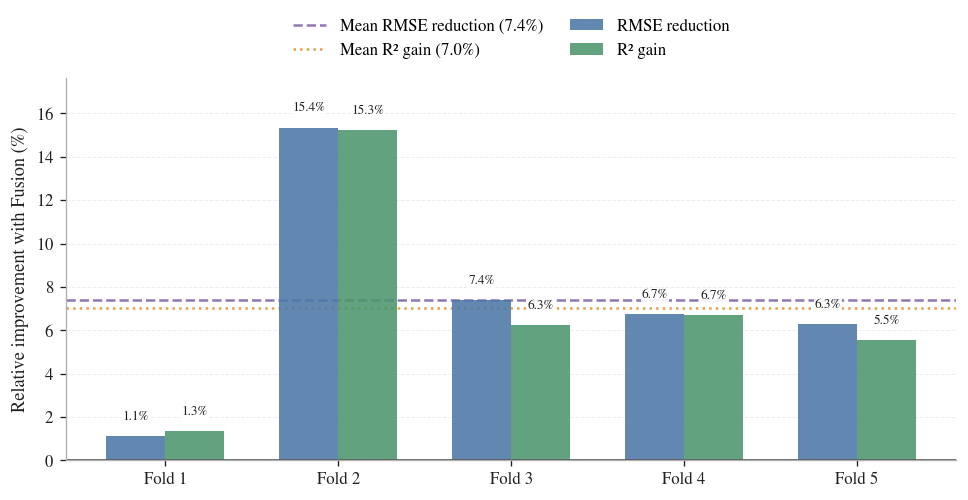

In [12]:
# Plot fold-wise relative improvements achieved by Fusion.
fig, axes = cnn_plots.plot_configuration_comparison(
    image_folds=image_only_fold_results,
    fusion_folds=cnn_fold_results,
    output_path=RESULTS_DIR / "cnn_configuration_comparison.png",
)
plt.show()


## 4. Common Hold-Out Evaluation

### 4.1 Final Fusion Performance

The final Fusion training duration is fixed as the median best epoch from development CV, then the model is refitted on all development observations and evaluated once on the common hold-out. The three supplementary dimensionless metrics are calculated on the same fixed hold-out predictions.


In [13]:
# Extract and cache embeddings for the locked common hold-out images.
HOLDOUT_CACHE = RESULTS_DIR / "holdout_efficientnet_b0_embeddings.npz"
holdout_embeddings, holdout_loaded_from_cache, holdout_extraction_seconds = (
    cnn_backbones.load_or_extract_backbone_embeddings(
        data=final_test_df,
        roi_config=ROI_CONFIG,
        cache_path=HOLDOUT_CACHE,
        device=DEVICE,
        backbone_name=BACKBONE_NAME,
        image_size=IMAGE_SIZE,
        batch_size=EMBEDDING_BATCH_SIZE,
    )
)

if holdout_loaded_from_cache:
    print("Loaded cached hold-out embeddings.")
else:
    print(f"Hold-out embedding extraction time: {holdout_extraction_seconds:.1f} s")
    print("Saved:", HOLDOUT_CACHE)

display(pd.DataFrame({
    "Item": ["Hold-out samples", "Embedding shape", "Loaded from cache"],
    "Value": [
        len(final_test_df),
        holdout_embeddings.shape,
        holdout_loaded_from_cache,
    ],
}))


Loaded cached hold-out embeddings.


,Item,Value
0,Hold-out samples,720
1,Embedding shape,"(720, 1280)"
2,Loaded from cache,True


In [14]:
# Refit Fusion on all development data and evaluate the common hold-out once.
FINAL_FUSION_EPOCHS = int(
    np.median(cnn_fold_results["Best Epoch"]).round()
)
holdout_tabular_matrix = final_test_df[TABULAR_FEATURES].to_numpy(
    dtype=np.float32
)
holdout_target_array = final_test_df[TARGET].to_numpy(dtype=np.float32)

fusion_holdout_output = cnn_training.fit_and_evaluate_fusion_holdout(
    development_embeddings=development_embeddings,
    development_tabular=tabular_matrix,
    development_targets=target_array,
    holdout_embeddings=holdout_embeddings,
    holdout_tabular=holdout_tabular_matrix,
    holdout_targets=holdout_target_array,
    device=DEVICE,
    epochs=FINAL_FUSION_EPOCHS,
    config=TRAINING_CONFIG,
    random_state=MODEL_RANDOM_STATE,
)

fusion_benchmark_result = cnn_cv_result.copy()
fusion_benchmark_result["Model"] = "EfficientNet-B0 Fusion"
fusion_benchmark_result["Test MAE"] = fusion_holdout_output["metrics"]["MAE"]
fusion_benchmark_result["Test RMSE"] = fusion_holdout_output["metrics"]["RMSE"]
fusion_benchmark_result["Test R2"] = fusion_holdout_output["metrics"]["R2"]
fusion_benchmark_result["Test MAPE"] = fusion_holdout_output["metrics"]["MAPE"]
fusion_benchmark_result["Test SMAPE"] = fusion_holdout_output["metrics"]["SMAPE"]
fusion_benchmark_result["Test NRMSE"] = fusion_holdout_output["metrics"]["NRMSE"]
fusion_benchmark_result["Train Time (s)"] = fusion_holdout_output["training_time"]
fusion_benchmark_result["Predict Time (s)"] = fusion_holdout_output["prediction_time"]

fusion_holdout_predictions = pd.DataFrame({
    "time": final_test_df["time"].to_numpy(),
    "Observed": fusion_holdout_output["observed"],
    "Predicted": fusion_holdout_output["predictions"],
})
fusion_holdout_predictions["Residual"] = (
    fusion_holdout_predictions["Observed"]
    - fusion_holdout_predictions["Predicted"]
)

display(pd.DataFrame({
    "Item": [
        "Final epochs", "Test MAE", "Test RMSE", "Test R²",
        "Test MAPE", "Test SMAPE", "Test NRMSE",
    ],
    "Value": [
        FINAL_FUSION_EPOCHS,
        fusion_holdout_output["metrics"]["MAE"],
        fusion_holdout_output["metrics"]["RMSE"],
        fusion_holdout_output["metrics"]["R2"],
        fusion_holdout_output["metrics"]["MAPE"],
        fusion_holdout_output["metrics"]["SMAPE"],
        fusion_holdout_output["metrics"]["NRMSE"],
    ],
}).round(3))

fusion_holdout_predictions.to_csv(
    RESULTS_DIR / "fusion_holdout_predictions.csv", index=False
)


,Item,Value
0,Final epochs,26.000
1,Test MAE,4.226
2,Test RMSE,5.610
3,Test R²,0.729
4,Test MAPE,52.507
5,Test SMAPE,36.625
6,Test NRMSE,40.112


### 4.2 Common Hold-Out Diagnostic

Observed and predicted concentrations are shown by PM2.5 range, with the residual distribution included as an inset.


,PM2.5 Range,Samples,Independent_Dates,MAE,Bias
0,≤20,571,38,3.405,1.305
1,20–35,110,24,7.145,-2.283
2,>35,39,5,8.018,-5.056


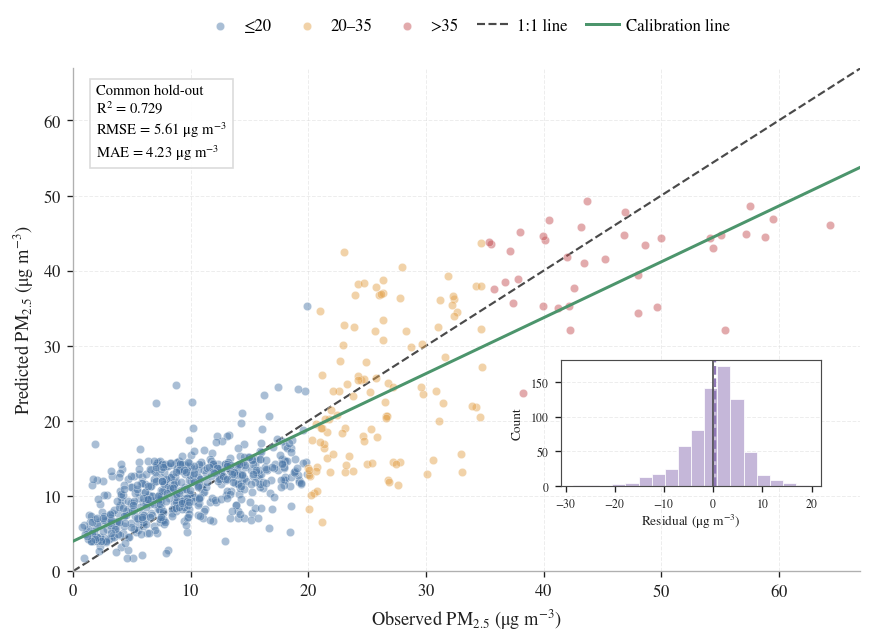

In [15]:
# Summarize concentration-dependent hold-out error and create the paper diagnostic.
diagnostic_predictions = fusion_holdout_predictions.copy()
diagnostic_predictions["Date"] = pd.to_datetime(
    diagnostic_predictions["time"]
).dt.normalize()
diagnostic_predictions["Error"] = (
    diagnostic_predictions["Predicted"]
    - diagnostic_predictions["Observed"]
)
diagnostic_predictions["Absolute Error"] = diagnostic_predictions["Error"].abs()

range_labels = ["≤20", "20–35", ">35"]
diagnostic_predictions["PM2.5 Range"] = pd.cut(
    diagnostic_predictions["Observed"],
    bins=[-np.inf, 20, 35, np.inf],
    labels=range_labels,
    include_lowest=True,
)
range_diagnostic = (
    diagnostic_predictions
    .groupby("PM2.5 Range", observed=False)
    .agg(
        Samples=("Absolute Error", "size"),
        Independent_Dates=("Date", "nunique"),
        MAE=("Absolute Error", "mean"),
        Bias=("Error", "mean"),
    )
    .reset_index()
)
display(range_diagnostic.round(3))

development_maximum = float(development_df[TARGET].max())
fig, axes = cnn_plots.plot_holdout_diagnostics(
    predictions=fusion_holdout_predictions,
    metrics=fusion_holdout_output["metrics"],
    development_maximum=development_maximum,
    output_path=RESULTS_DIR / "efficientnet_fusion_holdout_diagnostics.png",
)
range_diagnostic.to_csv(
    RESULTS_DIR / "efficientnet_holdout_concentration_diagnostic.csv",
    index=False,
)
plt.show()


## 5. All-Model Benchmark Comparison

The selected EfficientNet-B0 Fusion model is compared with the five feature-based benchmark models exported by Notebook 4 using identical development and common hold-out samples. MAE, RMSE, and R² remain the primary comparison metrics, while MAPE, SMAPE, and mean-normalised NRMSE provide supplementary dimensionless context.


In [16]:
# Combine the selected CNN with Notebook 4 benchmark results.
BENCHMARK_RESULTS_PATH = (
    PROJECT_ROOT / "results" / "model_benchmark"
    / "traditional_model_benchmark_results.csv"
)

if not BENCHMARK_RESULTS_PATH.exists():
    raise FileNotFoundError(
        "Run Notebook 4 through its common-hold-out export cell first."
    )

traditional_results = pd.read_csv(BENCHMARK_RESULTS_PATH)
traditional_context = traditional_results.copy()
traditional_context["Category"] = np.where(
    traditional_context["Model"] == "MLP",
    "Feature-based DNN",
    "Conventional ML",
)
traditional_context["Image Representation"] = "Handcrafted ROI"

fusion_context = fusion_benchmark_result.copy()
fusion_context["Category"] = "Pretrained CNN extension"
fusion_context["Image Representation"] = "Learned raw-ROI representation"

all_feature_comparison = pd.concat(
    [traditional_context, fusion_context],
    ignore_index=True,
    sort=False,
)

comparison_columns = [
    "Model", "Category", "Image Representation",
    "CV MAE", "CV RMSE", "CV R2",
    "Test MAE", "Test RMSE", "Test R2",
    "CV MAPE", "CV SMAPE", "CV NRMSE",
    "Test MAPE", "Test SMAPE", "Test NRMSE",
]
display(
    all_feature_comparison[comparison_columns]
    .rename(columns={"CV R2": "CV R²", "Test R2": "Test R²"})
    .round(3)
)

all_feature_comparison.to_csv(
    RESULTS_DIR / "development_model_comparison.csv",
    index=False,
)


,Model,Category,Image Representation,CV MAE,CV RMSE,CV R²,Test MAE,Test RMSE,Test R²,CV MAPE,CV SMAPE,CV NRMSE,Test MAPE,Test SMAPE,Test NRMSE
0,Ridge,Conventional ML,Handcrafted ROI,5.128,6.681,0.656,4.625,6.487,0.638,59.524,43.762,45.473,47.272,42.228,46.387
1,Decision Tree,Conventional ML,Handcrafted ROI,5.244,7.002,0.623,5.521,7.501,0.516,66.350,41.370,47.729,74.266,44.712,53.633
2,Random Forest,Conventional ML,Handcrafted ROI,4.673,6.199,0.702,4.467,5.866,0.704,58.992,37.564,42.358,60.840,38.740,41.940
3,Gradient Boosting,Conventional ML,Handcrafted ROI,4.380,5.810,0.739,4.063,5.583,0.732,49.858,35.926,39.663,45.345,36.091,39.921
4,MLP,Feature-based DNN,Handcrafted ROI,5.360,7.096,0.613,5.048,6.712,0.612,59.873,47.063,48.352,63.691,46.050,47.996
5,EfficientNet-B0 Fusion,Pretrained CNN extension,Learned raw-ROI representation,4.598,6.139,0.710,4.226,5.610,0.729,55.619,36.613,41.819,52.507,36.625,40.112


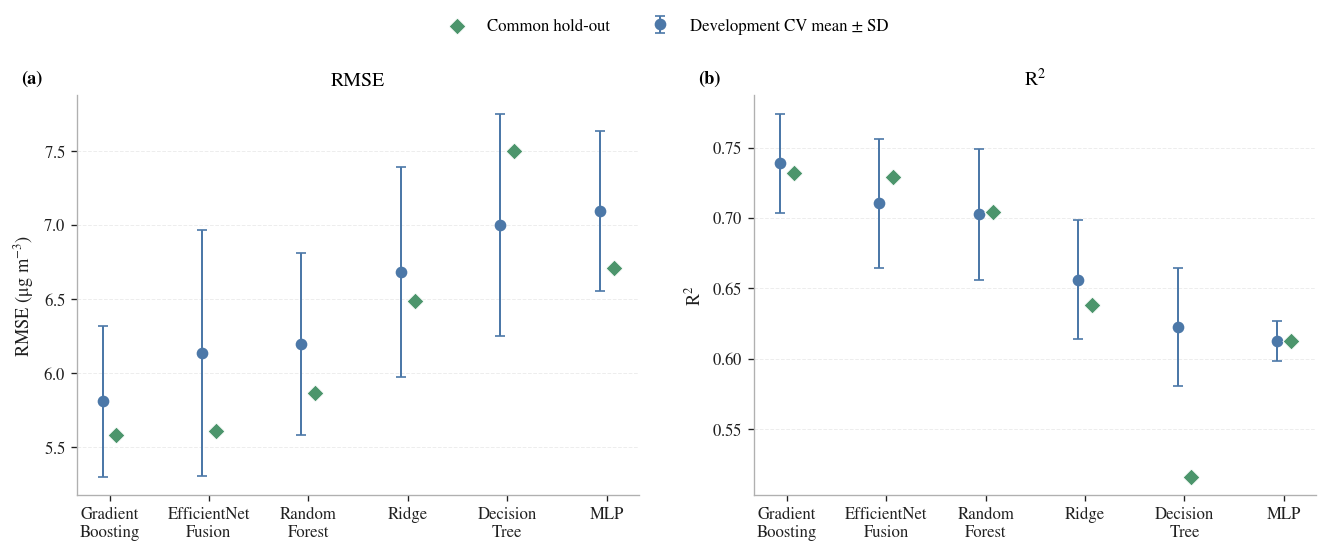

In [17]:
# Compare all models using both RMSE and R² under the shared protocol.
fig, axes = cnn_plots.plot_all_model_comparison(
    results=all_feature_comparison,
    output_path=RESULTS_DIR / "all_model_comparison.png",
)
plt.show()
